# Coding Exercise 2.1: Estimating scores with score matching

In Lecture 2 we saw that the score function
$$
x \mapsto \nabla \log \mu(x)
$$
can be estimated from samples without knowing the normalization constant of the density. The lecture first derives the **score matching** objective
$$
\mathbb E_{X \sim \mu}\big[\|s_\theta(X)\|_2^2 + 2\,\mathrm{div}(s_\theta)(X)\big],
$$
and then introduces the more practical **denoising score matching** (DSM) objective.

In this notebook you will

1. reuse the `Density` / `Sampleable` abstractions from Exercise 1,
2. implement the score matching and denoising score matching losses,
3. train a neural score estimator from samples only,
4. compare the learned score field with the exact score of a toy 2D distribution.

We test it on a 2D mixture of Gaussians


In [1]:
import numpy as np
from matplotlib import pyplot as plt

import torch
from torch import nn
from abc import ABC, abstractmethod
from tqdm.auto import tqdm

from util import Density, Sampleable, Gaussian, MixtureOfGaussians


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

np.random.seed(12345)
torch.manual_seed(12345)


Using device: cpu


## Section 1: A toy target distribution

We use the same kind of two-mode example as in Exercise 1.  The training algorithm will only see samples from the target distribution.


In [2]:

target_density = MixtureOfGaussians.two_modes_2D(distance=10.0, cov_scale=1.0).to(device)

num_train_samples = 10_000
train_samples = target_density.sample(num_train_samples).to(device)

print("Training sample shape:", tuple(train_samples.shape))


Training sample shape: (10000, 2)


In [3]:
# utility functions for plotting
def make_grid(scale: float = 10.0, bins: int = 81):
    x = torch.linspace(-scale, scale, bins)
    y = torch.linspace(-scale, scale, bins)
    X, Y = torch.meshgrid(x, y, indexing="ij")
    grid = torch.stack([X.flatten(), Y.flatten()], dim=1).to(device)
    return X, Y, grid


def plot_density_and_samples(density: Density, samples: torch.Tensor, title: str = "", scale: float = 10.0):
    X, Y, grid = make_grid(scale=scale, bins=121)
    with torch.no_grad():
        log_probs = density.log_prob(grid).cpu().numpy().reshape(X.shape)

    plt.figure(figsize=(8, 8))
    plt.contourf(X.cpu().numpy(), Y.cpu().numpy(), log_probs, levels=50, cmap="viridis")

    samples_p = samples.detach().cpu().numpy()
    plt.scatter(samples_p[:, 0], samples_p[:, 1], s=8, alpha=0.25, color="red", edgecolors="none")
    plt.title(title)
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.xlim(-scale, scale)
    plt.ylim(-scale, scale)
    plt.grid(alpha=0.2)
    plt.show()


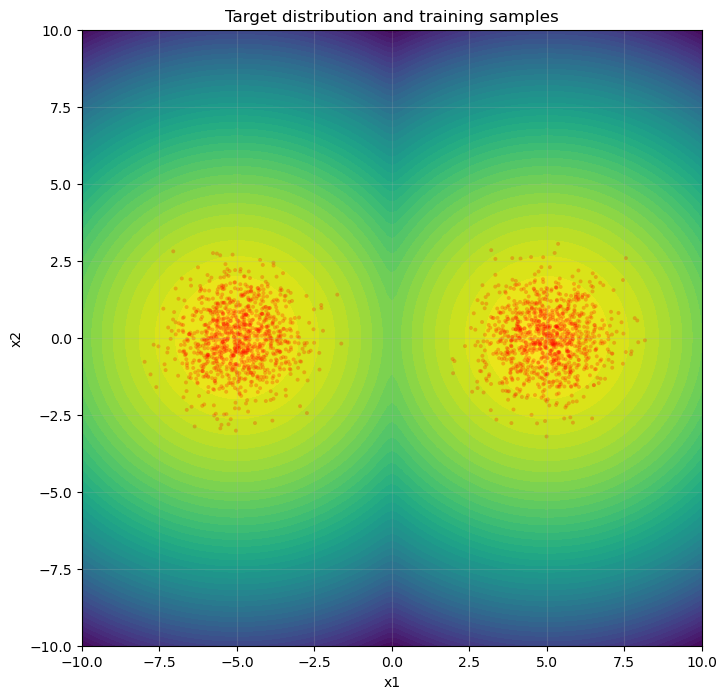

In [4]:
plot_density_and_samples(
    target_density,
    samples=train_samples[:2_000],
    title="Target distribution and training samples",
    scale=10.0,
)


## Section 2: A neural score model

We parameterize the score by a small multilayer perceptron
$$
s_\theta : \mathbb R^2 \to \mathbb R^2.
$$


In [5]:
class ScoreNet(nn.Module):
    def __init__(self, dim: int = 2, hidden_dim: int = 64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, dim),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


### 🧩 Question 2.1.1 — Classical score matching warm-up

In Lecture 2 the score matching objective is
$$
\mathbb E_{X \sim \mu}\left[\|s_\theta(X)\|_2^2 + 2\,\mathrm{div}(s_\theta)(X)\right].
$$

1. Re-derive this formula from the Fisher-divergence objective by integration by parts.
2. Implement the divergence $\mathrm{div}(s_\theta)(x)$ and the corresponding loss below.

We will mainly train with **denoising score matching** later because it is much cheaper in practice, but it is important to understand where it comes from.


In [6]:
def divergence_of_score(score_model: nn.Module, x: torch.Tensor) -> torch.Tensor:
    """
    Compute div(s_theta)(x) for a batch of inputs x.

    Returns
    -------
    torch.Tensor
        Tensor of shape (batch_size,) containing the divergence at each point.
    """
    x = x.detach().requires_grad_(True)
    score = score_model(x)

    div = torch.zeros(x.shape[0], device=x.device, dtype=x.dtype)
    for i in range(x.shape[1]):
        grad_i = torch.autograd.grad(
            score[:, i].sum(),
            x,
            create_graph=True,
            retain_graph=True,
        )[0][:, i]
        div = div + grad_i
    return div


def score_matching_loss(score_model: nn.Module, x: torch.Tensor) -> torch.Tensor:
    """
    Implements
        E [ ||s_theta(X)||_2^2 + 2 div(s_theta)(X) ].
    """
    x = x.detach().requires_grad_(True)
    score = score_model(x)

    div = torch.zeros(x.shape[0], device=x.device, dtype=x.dtype)
    for i in range(x.shape[1]):
        grad_i = torch.autograd.grad(
            score[:, i].sum(),
            x,
            create_graph=True,
            retain_graph=True,
        )[0][:, i]
        div = div + grad_i

    norm_sq = (score ** 2).sum(dim=1)
    return (norm_sq + 2.0 * div).mean()

In [7]:

# Optional sanity check after you implement the two functions above.
#
# score_model_debug = ScoreNet().to(device)
# debug_batch = train_samples[:32].clone().detach()
# debug_loss = score_matching_loss(score_model_debug, debug_batch)
# print("Score matching loss on a mini-batch:", debug_loss.item())


### 🧩 Question 2.1.2 — Denoising score matching

Let
$$
Y = X + \sigma \varepsilon, \qquad X \sim \mu,\ \varepsilon \sim \mathcal N(0, I_2).
$$
Lecture 2 shows that the denoising score matching objective can be written as
$$
\mathbb E\left[\left\|s_\theta(Y) + \frac{\varepsilon}{\sigma}\right\|_2^2\right].
$$

Implement the loss below.  This is the practical objective we will actually train with.


In [8]:
def denoising_score_matching_loss(score_model: nn.Module, x: torch.Tensor, sigma: float) -> torch.Tensor:
    """
    Implements
        E || s_theta(x + sigma * eps) + eps / sigma ||^2
    with eps ~ N(0, I).
    """
    eps = torch.randn_like(x)
    y = x + sigma * eps
    predicted_score = score_model(y)
    residual = predicted_score + eps / sigma
    return (residual ** 2).sum(dim=1).mean()


### 🧩 Question 2.1.3 — Train the score network

We now train the score network with DSM on samples from the target distribution.

**Note.**  
Because DSM with fixed `sigma` learns the score of the **smoothed density**
$$
\nu = \mu * \mathcal N(0, \sigma^2 I),
$$
we will compare the learned score to that smoothed target, not to the original distribution.


In [9]:

sigma = 0.75

score_model = ScoreNet(dim=2, hidden_dim=64).to(device)
optimizer = torch.optim.Adam(score_model.parameters(), lr=1e-3)

batch_size = 256
num_steps = 1_000
loss_history = []

for step in tqdm(range(num_steps)):
    batch_idx = torch.randint(0, train_samples.shape[0], (batch_size,), device=device)
    batch = train_samples[batch_idx]

    loss = denoising_score_matching_loss(score_model, batch, sigma)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    loss_history.append(loss.item())


  0%|          | 0/1000 [00:00<?, ?it/s]

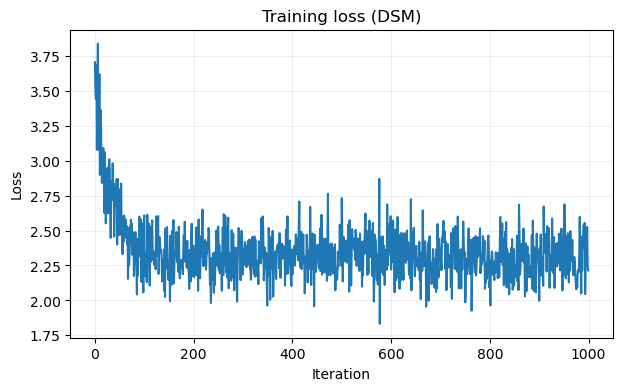

In [10]:

plt.figure(figsize=(7, 4))
plt.plot(loss_history)
plt.title("Training loss (DSM)")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.grid(alpha=0.2)
plt.show()


### 🧩 Question 2.1.4 — Compare with the exact score

For a mixture of Gaussians, smoothing by Gaussian noise keeps us inside the same family:
if the original component covariance is $\Sigma_k$, then the smoothed covariance becomes
$$
\Sigma_k + \sigma^2 I.
$$

Construct the smoothed density and compare its exact score field to the network prediction.


In [11]:

smooth_covs = target_density.covs + (sigma ** 2) * torch.eye(target_density.dim, device=device).unsqueeze(0)
smoothed_density = MixtureOfGaussians(
    target_density.means,
    smooth_covs,
    target_density.weights,
).to(device)


In [12]:

def plot_score_field_comparison(
    exact_density: Density,
    score_model: nn.Module,
    title_suffix: str = "",
    scale: float = 10.0,
    bins: int = 31,
    stride: int = 2,
):
    X, Y, grid = make_grid(scale=scale, bins=bins)

    with torch.no_grad():
        log_probs = exact_density.log_prob(grid).cpu().numpy().reshape(X.shape)
        predicted_score = score_model(grid).cpu().numpy().reshape(bins, bins, 2)

    exact_score = exact_density.score(grid).detach().cpu().numpy().reshape(bins, bins, 2)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    for ax, score, title in zip(
        axes,
        [exact_score, predicted_score],
        [f"Exact score {title_suffix}", f"Learned score {title_suffix}"],
    ):
        ax.contourf(X.cpu().numpy(), Y.cpu().numpy(), log_probs, levels=40, cmap="viridis")
        ax.quiver(
            X.cpu().numpy()[::stride, ::stride],
            Y.cpu().numpy()[::stride, ::stride],
            score[::stride, ::stride, 0],
            score[::stride, ::stride, 1],
            color="white",
            alpha=0.9,
        )
        ax.set_title(title)
        ax.set_xlabel("x1")
        ax.set_ylabel("x2")
        ax.set_xlim(-scale, scale)
        ax.set_ylim(-scale, scale)
        ax.grid(alpha=0.2)

    plt.tight_layout()
    plt.show()


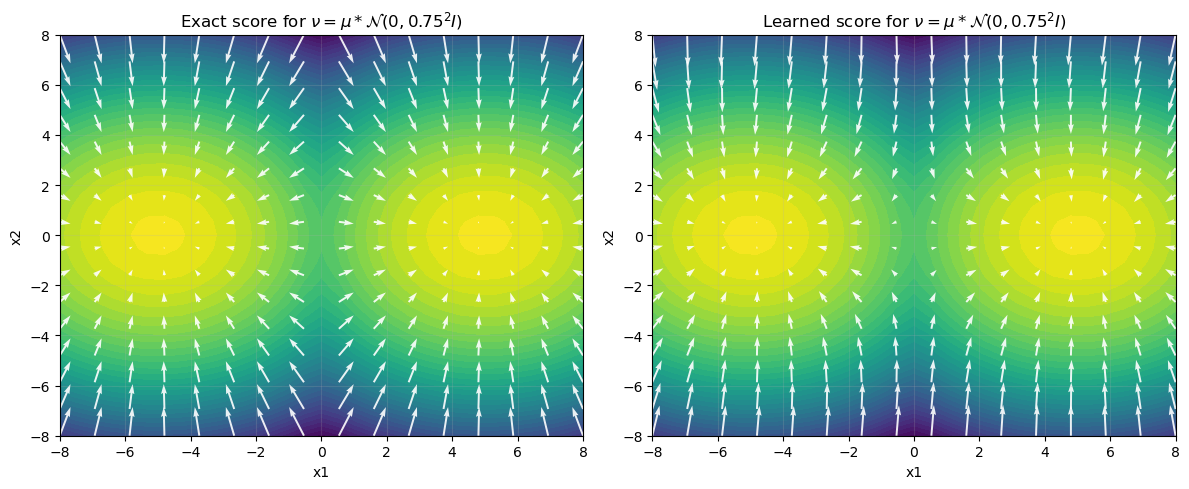

In [13]:
plot_score_field_comparison(
    smoothed_density,
    score_model,
    title_suffix=rf"for $\nu = \mu * \mathcal{{N}}(0, {sigma}^2 I)$",
    scale=8.0,
)


In [14]:

X, Y, grid = make_grid(scale=10.0, bins=61)

with torch.no_grad():
    predicted_score = score_model(grid)

exact_score = smoothed_density.score(grid)
mse = ((predicted_score - exact_score) ** 2).sum(dim=1).mean().item()

print(f"Grid MSE against the exact score of the smoothed density: {mse:.4f}")


Grid MSE against the exact score of the smoothed density: 1.1033


### 🧩 Question 2.1.5 — Discussion

Answer the following in a markdown cell below.

1. Where is the score easiest to estimate: near the modes, or in the low-density region between the modes?
2. What changes when you increase or decrease `sigma`?
3. Why does DSM learn the score of the smoothed density instead of the original density?